Roll No.: 10

Name: Shubham Khairnar

Date of Performance: 4 Mar 2026

Problem Statement: Implement a Deep Q-Network (DQN) using a deep neural network library (e.g., TensorFlow or PyTorch) and train it on a simple environment like CartPole or Mountain Car.

In [ ]:
!pip install gymnasium torch numpy matplotlib

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt

In [ ]:
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()

        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [ ]:
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size

        self.gamma = 0.99
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.lr = 0.001
        self.batch_size = 64

        self.memory = deque(maxlen=2000)

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = DQN(state_size, action_size).to(self.device)
        self.target_model = DQN(state_size, action_size).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

        self.update_target()

    def update_target(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)

        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        q_values = self.model(state)
        return torch.argmax(q_values).item()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < self.batch_size:
            return

        batch = random.sample(self.memory, self.batch_size)

        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(states).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)

        q_values = self.model(states).gather(1, actions).squeeze()
        next_q_values = self.target_model(next_states).max(1)[0]

        target = rewards + self.gamma * next_q_values * (1 - dones)

        loss = nn.MSELoss()(q_values, target.detach())

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [ ]:
def train():
    env = gym.make("CartPole-v1")

    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    agent = DQNAgent(state_size, action_size)

    episodes = 300
    scores = []

    for e in range(episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False

        while not done:
            action = agent.act(state)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.remember(state, action, reward, next_state, done)
            agent.replay()

            state = next_state
            total_reward += reward

        agent.update_target()
        scores.append(total_reward)

        print(f"Episode {e+1}, Score: {total_reward}")

    return agent, scores

Episode 1, Score: 12.0
Episode 2, Score: 20.0


/tmp/ipykernel_10077/1118718048.py:45: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor(states).to(self.device)


Episode 3, Score: 36.0
Episode 4, Score: 42.0
Episode 5, Score: 15.0
Episode 6, Score: 28.0
Episode 7, Score: 13.0
Episode 8, Score: 27.0
Episode 9, Score: 12.0
Episode 10, Score: 28.0
Episode 11, Score: 25.0
Episode 12, Score: 55.0
Episode 13, Score: 94.0
Episode 14, Score: 33.0
Episode 15, Score: 24.0
Episode 16, Score: 30.0
Episode 17, Score: 50.0
Episode 18, Score: 27.0
Episode 19, Score: 31.0
Episode 20, Score: 139.0
Episode 21, Score: 135.0
Episode 22, Score: 163.0
Episode 23, Score: 185.0
Episode 24, Score: 214.0
Episode 25, Score: 226.0
Episode 26, Score: 213.0
Episode 27, Score: 201.0
Episode 28, Score: 205.0
Episode 29, Score: 235.0
Episode 30, Score: 243.0
Episode 31, Score: 170.0
Episode 32, Score: 195.0
Episode 33, Score: 217.0
Episode 34, Score: 216.0
Episode 35, Score: 245.0
Episode 36, Score: 225.0
Episode 37, Score: 228.0
Episode 38, Score: 182.0
Episode 39, Score: 247.0
Episode 40, Score: 205.0
Episode 41, Score: 261.0
Episode 42, Score: 225.0
Episode 43, Score: 330.0

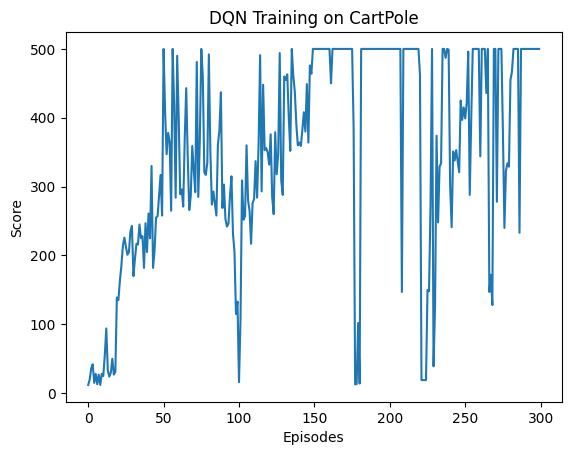

In [ ]:
agent, scores = train()

plt.plot(scores)
plt.xlabel("Episodes")
plt.ylabel("Score")
plt.title("DQN Training on CartPole")
plt.show()

In [ ]:
def evaluate(agent):
    import gymnasium as gym

    env = gym.make("CartPole-v1", render_mode="human")

    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        action = torch.argmax(agent.model(state_tensor)).item()

        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

    print("Evaluation Score:", total_reward)
    env.close()

evaluate(agent)

Evaluation Score: 304.0


In [ ]:
def test(agent):
    env = gym.make("CartPole-v1", render_mode="human")

    state, _ = env.reset()
    done = False

    while not done:
        action = agent.act(state)
        state, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

    env.close()

test(agent)